In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dataset_file.csv")

In [3]:
df.head(10)

,customer_id,starting_date,suspension_date,observation_end_date,duration_days,event,age,income,annual_premium,has_children,marital_status,home_owner,college_degree,good_credit,county
0,2.213000e+11,2018-12-09,NaN,2022-12-02,1454,0,44.474,22500.000,818.877997,1.0,Married,1.0,1.0,1.0,Kaufman
1,2.213001e+11,2018-01-02,NaN,2022-12-02,1795,0,72.559,27500.000,974.199182,0.0,Single,1.0,0.0,0.0,Dallas
2,2.213007e+11,2009-09-23,NaN,2022-12-02,4818,0,55.444,42500.000,967.375112,0.0,Married,1.0,0.0,0.0,Dallas
3,2.213016e+11,2006-10-11,NaN,2022-12-02,5896,0,50.220,87500.000,784.633494,1.0,Married,1.0,1.0,1.0,Tarrant
4,2.213027e+11,2021-08-05,NaN,2022-12-02,484,0,32.641,52500.000,909.916163,0.0,Married,1.0,0.0,1.0,Dallas
5,2.213007e+11,2014-12-28,NaN,2022-12-02,2896,0,70.806,125000.000,1084.048271,1.0,Married,1.0,0.0,1.0,Denton
6,2.213022e+11,2011-09-15,NaN,2022-12-02,4096,0,45.969,47500.000,1277.370767,0.0,Married,1.0,0.0,1.0,Collin
7,2.213029e+11,2017-02-24,2022-12-01,2022-12-01,2106,1,56.389,47500.000,917.201036,0.0,Single,1.0,1.0,1.0,Tarrant
8,2.213012e+11,2013-08-24,NaN,2022-12-02,3387,0,64.307,32500.000,1095.390747,0.0,Married,1.0,0.0,0.0,Dallas
9,2.213015e+11,2022-09-13,2022-09-16,2022-09-16,3,1,55.444,80372.176,966.838986,0.0,Unknown,0.0,1.0,0.0,Tarrant


In [4]:
df.shape

(2197537, 15)

In [5]:
df.isna().sum()

customer_id                   0
starting_date                 0
suspension_date         2011000
observation_end_date          0
duration_days                 0
event                         0
age                      161573
income                   161573
annual_premium                0
has_children             161573
marital_status                0
home_owner               161573
college_degree           161573
good_credit              161573
county                        0
dtype: int64

In [6]:
print(df[["starting_date", "suspension_date", "observation_end_date"]].head())

  starting_date suspension_date observation_end_date
0    2018-12-09             NaN           2022-12-02
1    2018-01-02             NaN           2022-12-02
2    2009-09-23             NaN           2022-12-02
3    2006-10-11             NaN           2022-12-02
4    2021-08-05             NaN           2022-12-02


In [7]:
print("Total rows:", len(eda_sample))

print(
    "Unique customers:",
    df["customer_id"].nunique()
)

NameError: name 'eda_sample' is not defined

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(50000, 15)

In [ ]:
df["starting_date"] = pd.to_datetime(df["starting_date"])
df["observation_end_date"] = pd.to_datetime(df["observation_end_date"])

In [ ]:
# Customer demographics 
# to know Who our customers are and how their age, income, and demographics are distributed.
df[["age",
    "income",
    "annual_premium",
    "duration_days"
]].describe().round(1)

print("\nMarital status:",df["marital_status"].value_counts())

print("\nTop 10 counties:",df["county"].value_counts().head(10))


Marital status: marital_status
Married    23084
Single     13863
Unknown    13053
Name: count, dtype: int64

Top 10 counties: county
Dallas      19102
Tarrant     14318
Collin       6390
Denton       5400
Ellis        1233
Kaufman       912
Parker        753
Johnson       708
Rockwall      654
Unknown       397
Name: count, dtype: int64


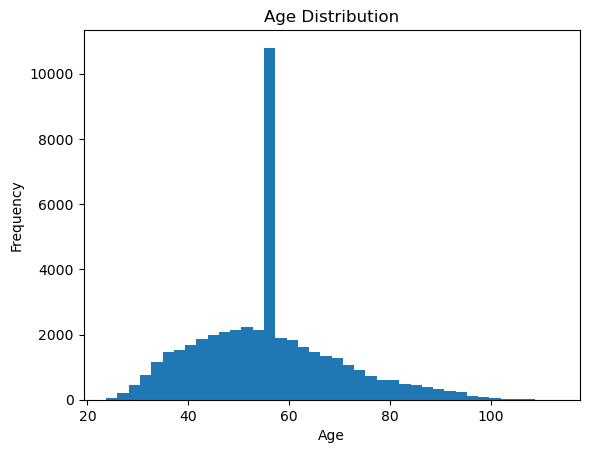

In [ ]:
# visualization 
df["age"].plot(kind="hist", bins=40)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

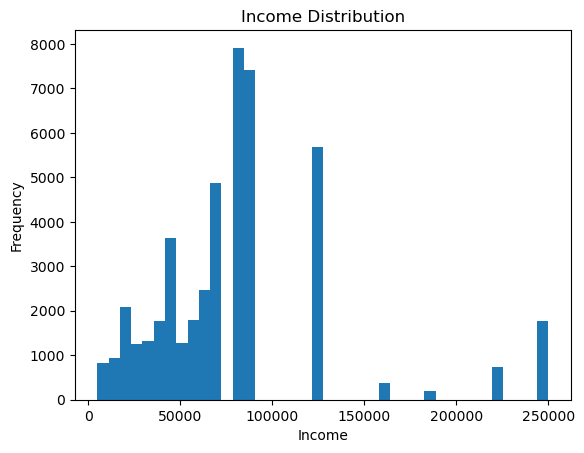

In [ ]:
df["income"].plot(kind="hist", bins=40)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.show()

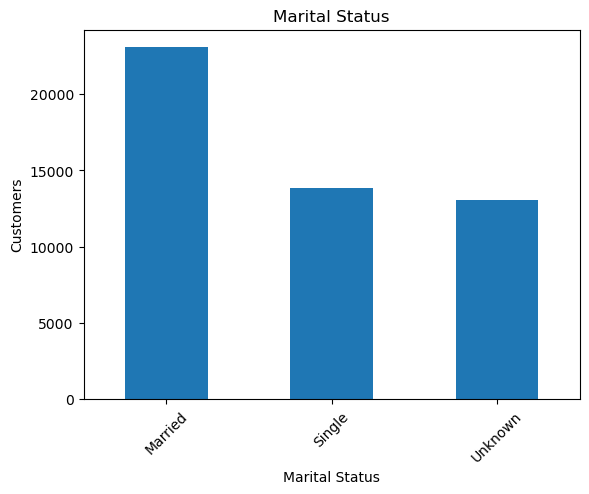

In [ ]:
df["marital_status"].value_counts().plot(kind="bar")

plt.title("Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Customers")
plt.xticks(rotation=45)

plt.show()

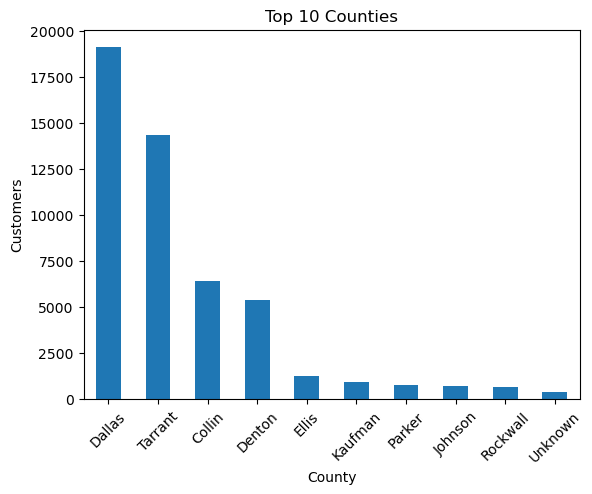

In [ ]:
df["county"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Counties")
plt.xlabel("County")
plt.ylabel("Customers")

plt.xticks(rotation=45)
plt.show()

In [ ]:
# Active vs. Lapsed customers 
print("ACTIVE VS LAPSED\n",df["event"].value_counts())

print("Lapse rate:\n",df["event"].mean() * 100)

ACTIVE VS LAPSED
 event
0    45816
1     4184
Name: count, dtype: int64
Lapse rate:
 8.368


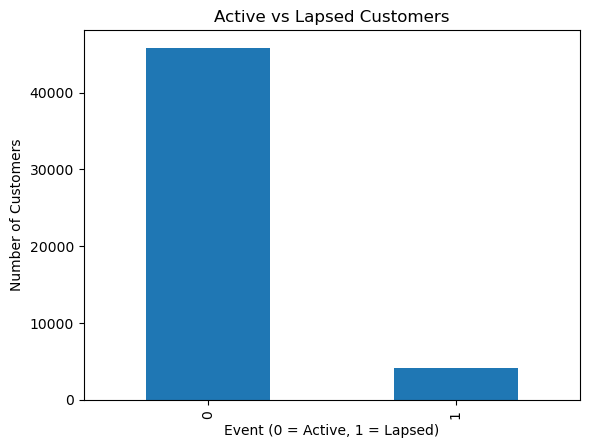

In [ ]:
# visualization 
df["event"].value_counts().plot(kind="bar")
plt.title("Active vs Lapsed Customers")
plt.xlabel("Event (0 = Active, 1 = Lapsed)")
plt.ylabel("Number of Customers")

plt.show()
# getting to know how many customers experienced the event and how many remained censored.

In [ ]:
# comparing age, income and premium (using lapse status)
# # to know how customer characteristics differ between the two event groups
print("AVERAGE VALUES BY EVENT\n",
    df.groupby("event")[["age", "income", "annual_premium"]].mean().round(2)
)

AVERAGE VALUES BY EVENT
          age    income  annual_premium
event                                 
0      55.70  80753.29          929.02
1      55.18  79547.39          940.31


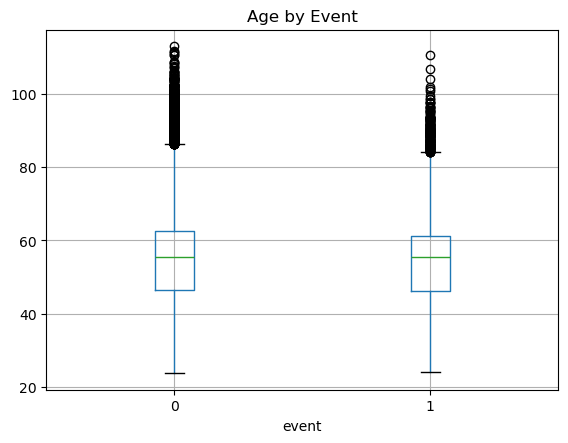

In [ ]:
# visualization 
df.boxplot(column="age",by="event")
plt.title("Age by Event")
plt.suptitle("")

plt.show()

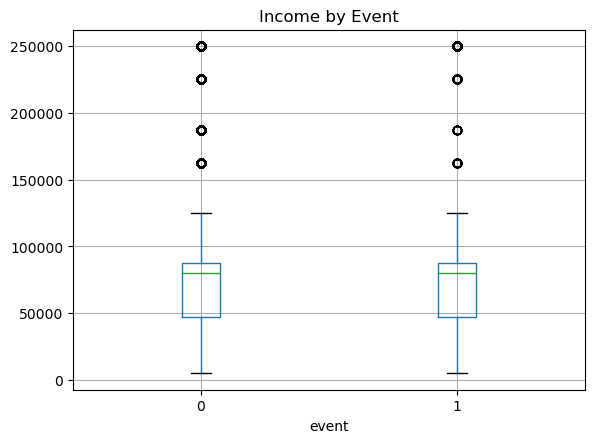

In [ ]:
df.boxplot(column="income",by="event")
plt.title("Income by Event")
plt.suptitle("")

plt.show()

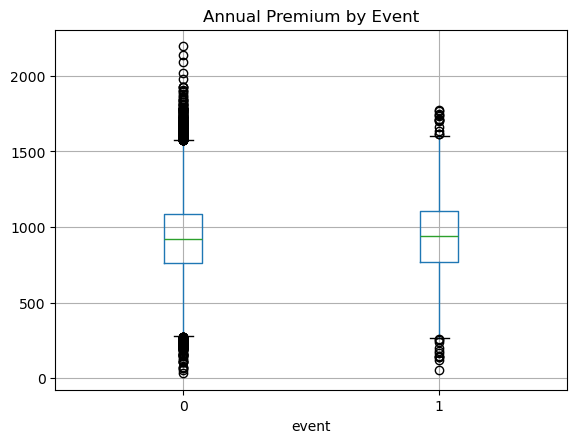

In [ ]:
df.boxplot(
    column="annual_premium",
    by="event"
)

plt.title("Annual Premium by Event")
plt.suptitle("")

plt.show()

In [ ]:
# Survival duration distribution
df["duration_years"] = df["duration_days"] / 365.25
df["duration_years"].describe().round(2)

count    50000.00
mean         9.84
std          6.20
min          0.00
25%          4.09
50%          9.89
75%         17.22
max         17.22
Name: duration_years, dtype: float64

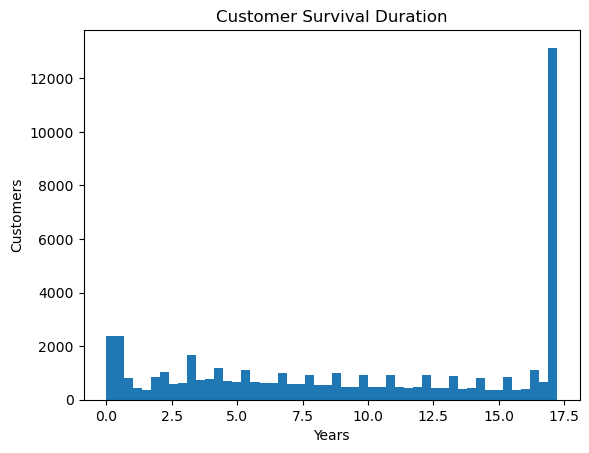

In [ ]:
# visualization 
# to know how long customers were observed in the dataset.
df["duration_years"].plot(
    kind="hist",
    bins=50
)

plt.title("Customer Survival Duration")
plt.xlabel("Years")
plt.ylabel("Customers")

plt.show()

In [ ]:
%pip install lifelines

Note: you may need to restart the kernel to use updated packages.


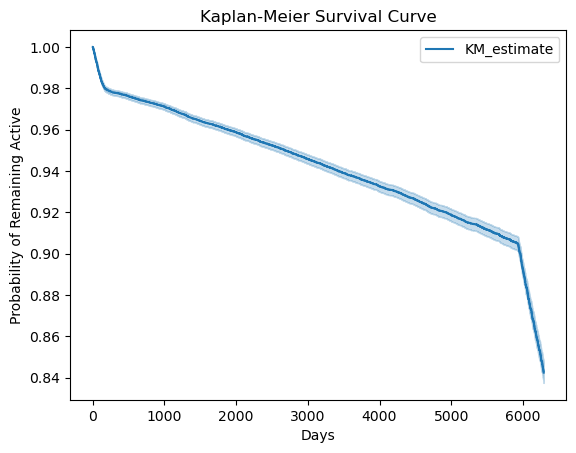

In [ ]:
# Kaplan-meier survival curve 
from lifelines import KaplanMeierFitter

km = KaplanMeierFitter()

km.fit(
    durations = df["duration_days"],
    event_observed = df["event"]
)

km.plot_survival_function()

plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Days")
plt.ylabel("Probability of Remaining Active")

plt.show()

Lapse rate by
 marital_status
marital_status
Married    8.46
Single     8.18
Unknown    8.40
Name: event, dtype: float64


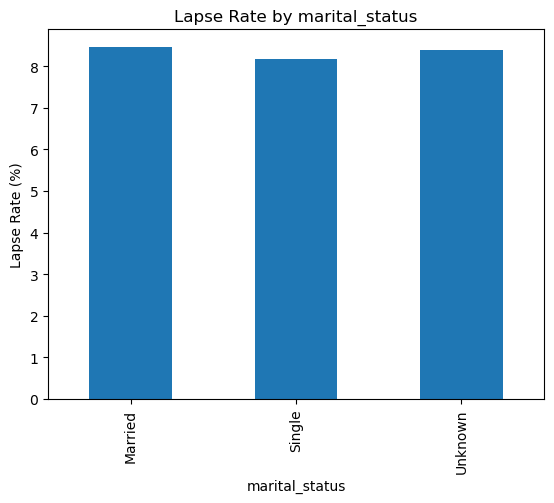

Lapse rate by
 home_owner
home_owner
0.0    8.43
1.0    8.32
Name: event, dtype: float64


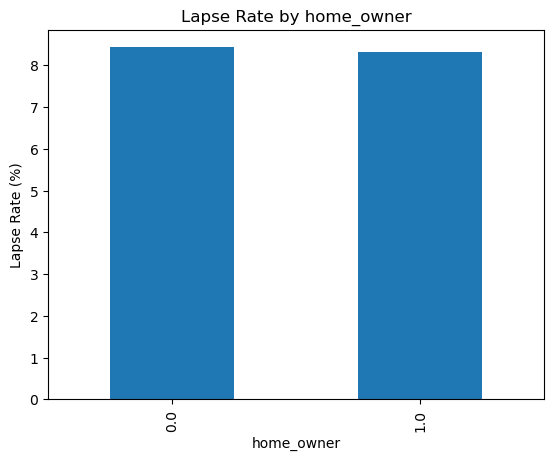

Lapse rate by
 good_credit
good_credit
0.0    8.63
1.0    8.29
Name: event, dtype: float64


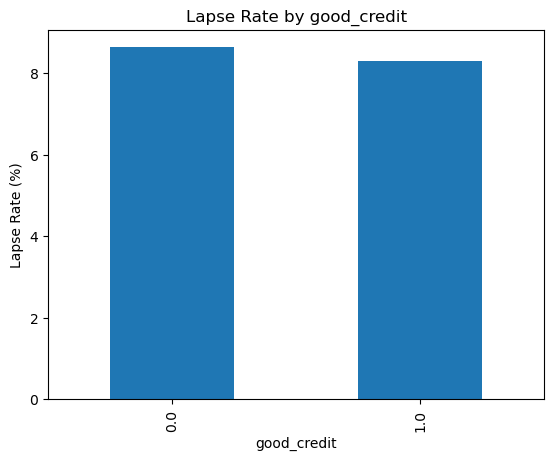

Lapse rate by
 has_children
has_children
0.0    8.16
1.0    8.60
Name: event, dtype: float64


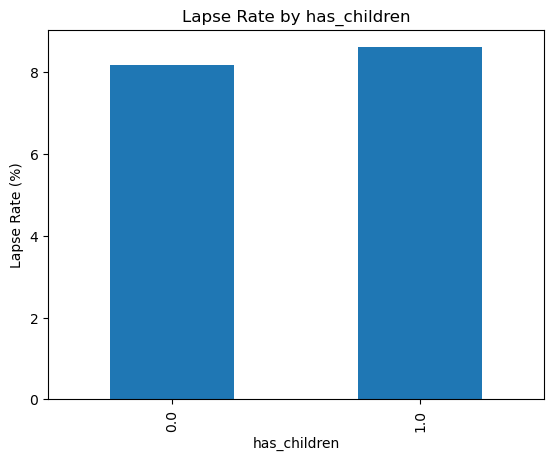

In [ ]:
# reln b/w - Characteristics and Lapse
# to know whether the observed event rate differs across customer groups.
columns = ["marital_status", "home_owner", "good_credit", "has_children"]
for column in columns:
    lapse_rate = df.groupby(column)["event"].mean().mul(100).round(2)
    print("Lapse rate by\n", column)
    print(lapse_rate)

    lapse_rate.plot(kind="bar")
    plt.title("Lapse Rate by " + column)
    plt.ylabel("Lapse Rate (%)")
    plt.xlabel(column)
    plt.show()    # plotting lapse_rate for each -- in the loop

In [ ]:
# corr
columns = [
    "age",
    "income",
    "annual_premium",
    "has_children",
    "home_owner",
    "college_degree",
    "good_credit",
    "event"
]
print(df[columns].corr()["event"].sort_values())

college_degree   -0.013197
age              -0.010485
income           -0.006633
good_credit      -0.004716
home_owner       -0.001729
has_children      0.007866
annual_premium    0.012832
event             1.000000
Name: event, dtype: float64


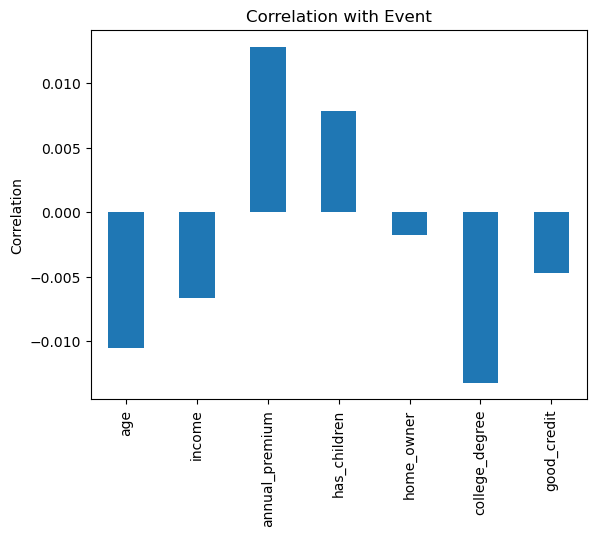

In [ ]:
# visualization
df[columns].corr()["event"].drop("event").plot(kind="bar")
plt.title("Correlation with Event")
plt.ylabel("Correlation")

plt.show()

In [ ]:
df.to_csv("eda_dataset.csv",
    index=False
)
print("EDA dataset saved successfully!")

EDA dataset saved successfully!
